In [86]:
#!/usr/bin/env python
# coding: utf-8

In [87]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, BatchNormalization, Dropout
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import h5py
import os
from scipy.interpolate import interp1d
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Function to generate file names based on the input format

In [88]:
name_format = "FCNN_run3"
file_path = os.path.join('MATLAB_DATA', 'results8.mat')  # Replace with your actual file path
def generate_filename(base_name, extension):
    return f"{name_format}_{base_name}.{extension}"

In [89]:
import os
import scipy.io
import h5py
import numpy as np
from scipy.interpolate import interp1d

# Define the list of files that should be processed as HDF5 files
h5_file_numbers = {3, 6, 7}

# Function to load data from .h5 file
def load_h5_data(file_path):
    with h5py.File(file_path, 'r') as hdf:
        results_group = hdf['results']
        B_MAG_refs = results_group['B_MAG'][()]
        EDC_MAG_refs = results_group['EDC_MAG'][()]
        X_refs = results_group['X'][()]
        I_refs = results_group['I'][()]
        B_MAG_raw = [hdf[ref][()] for ref in B_MAG_refs.flatten()]
        EDC_MAG_raw = [hdf[ref][()] for ref in EDC_MAG_refs.flatten()]
        X_raw = [hdf[ref][()] for ref in X_refs.flatten()]
        I_raw = [hdf[ref][()] for ref in I_refs.flatten()]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

# Function to load data from .mat file
def load_mat_data(file_path):
    mat_contents = scipy.io.loadmat(file_path)
    results = mat_contents['results']
    B_MAG_raw = [result['B_MAG'][0] for result in results[0]]
    EDC_MAG_raw = [result['EDC_MAG'][0] for result in results[0]]
    X_raw = [result['X'][0] for result in results[0]]  # Scaling X values
    I_raw = [result['I'][0] for result in results[0]]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

# Function to resample and smooth data
def resample_and_smooth(X, I, new_length):
    X_new = np.linspace(6562.3, 6563.3, num=new_length)
    f = interp1d(X, I, kind='cubic', fill_value="extrapolate")
    I_new = f(X_new)
    return X_new, I_new

# Function to process data
def process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw, fixed_length=1200):
    X_data, I_data, B_MAG_data, EDC_MAG_data = [], [], [], []
    for i in range(len(X_raw)):
        X = np.squeeze(X_raw[i])
        I = np.squeeze(I_raw[i])
        B = np.squeeze(B_MAG_raw[i])
        EDC = np.squeeze(EDC_MAG_raw[i])
        X_scaled = X * 10**10
        X_resampled, I_resampled = resample_and_smooth(X_scaled, I, fixed_length)
        X_data.append(X_resampled)
        I_data.append(I_resampled)
        B_MAG_data.append(B)
        EDC_MAG_data.append(EDC)
    return np.array(B_MAG_data), np.array(EDC_MAG_data), np.array(X_data), np.array(I_data)

# Main function to determine the type of file and load data accordingly
def load_and_process_file(file_path):
    file_name = os.path.basename(file_path)
    
    # Extract the file number (e.g., results1, results5, etc.)
    file_number = int(file_name.lstrip('results').rstrip('.mat'))
    
    if file_number in h5_file_numbers:
        # It's an HDF5 file
        print(f"Processing {file_name} as an HDF5 file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_h5_data(file_path)
    else:
        # It's a standard .mat file
        print(f"Processing {file_name} as a .mat file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_mat_data(file_path)
    
    # Process the loaded data
    B_MAG_data, EDC_MAG_data, X_data, I_data = process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw)
    
    return B_MAG_data, EDC_MAG_data, X_data, I_data

# Example usage
B_MAG_data, EDC_MAG_data, X_data, I_data = load_and_process_file(file_path)

# Data is now loaded and processed.
print("Data processing completed.")


Processing results8.mat as a .mat file...


KeyboardInterrupt: 

Filter out low-variance columns

In [ ]:
means = np.mean(I_data, axis=0)
stds = np.std(I_data, axis=0)
start_index, end_index = 0, I_data.shape[1] - 1

In [ ]:
for i in range(I_data.shape[1]):
    if stds[i] >= 0.01:
        start_index = i
        break

In [ ]:
for i in range(I_data.shape[1] - 1, -1, -1):
    if stds[i] >= 0.01:
        end_index = i
        break

In [ ]:
X_resampled=X_data[0]
I_data_filtered = I_data[:, start_index:end_index + 1]
X_resampled_filtered = X_resampled[start_index:end_index + 1]
means_filtered = means[start_index:end_index + 1]
stds_filtered = stds[start_index:end_index + 1]
normalized_I = (I_data_filtered - means_filtered) / stds_filtered

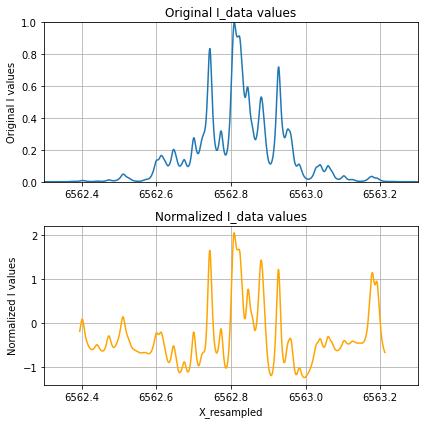

In [ ]:
import matplotlib.pyplot as plt
# Row 10 of original and normalized data
index = 200
original_row = I_data[index]
normalized_row = normalized_I[index]

# Create the figure and subplots
plt.figure(figsize=(6, 6))

# Top plot: Original I_data values for row 10
plt.subplot(2, 1, 1)
plt.plot(X_resampled, original_row, label='Original I_data')
plt.title('Original I_data values')
plt.ylabel('Original I values')
plt.ylim(0, 1)
plt.xlim(6562.3, 6563.3)
plt.grid(True)

# Bottom plot: Normalized I_data values for row 10
plt.subplot(2, 1, 2)
plt.plot(X_resampled_filtered, normalized_row, label='Normalized I_data', color='orange')
plt.title('Normalized I_data values')
plt.xlabel('X_resampled')
plt.ylabel('Normalized I values')
plt.xlim(6562.3, 6563.3)
plt.grid(True)

# Adjust layout and display the figure
plt.tight_layout()
plt.show()

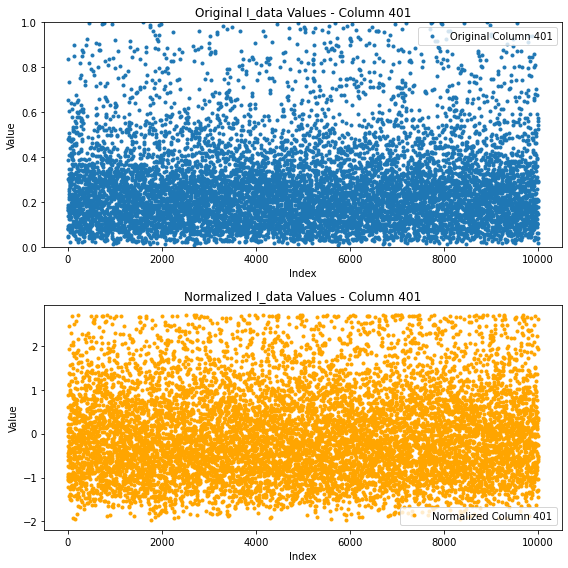

In [ ]:
# Extract the 10th column (index 9 in zero-indexed Python)
index = 400
original_column = I_data[:, index]
normalized_column = normalized_I[:, index]

# Create the figure with two subplots
plt.figure(figsize=(8, 8))

# Top figure: Original values of column 10
plt.subplot(2, 1, 1)
plt.plot(original_column, '.', label=f'Original Column {index+1}')
plt.title(f'Original I_data Values - Column {index+1}')
plt.ylim(0, 1)
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()

# Bottom figure: Normalized values of column 10
plt.subplot(2, 1, 2)
plt.plot(normalized_column, '.', label=f'Normalized Column {index+1}', color='orange')
plt.title(f'Normalized I_data Values - Column {index+1}')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

Flatten the I_data to use as input for the neural network

In [ ]:
I_data_flat = normalized_I.reshape(normalized_I.shape[0], -1)

Stack the B and E components to create the output (target) data

In [ ]:
target_data = np.column_stack((B_MAG_data, EDC_MAG_data))

Split the data into training and testing sets

In [ ]:
I_train, I_test, target_train, target_test = train_test_split(I_data_flat, target_data, test_size=0.2, random_state=42)
B_train = target_train[:, :3]
E_train = target_train[:, 3:]
B_test = target_test[:, :3]
E_test = target_test[:, 3:]

scaler_B1 = MinMaxScaler()
scaler_B2 = MinMaxScaler()
scaler_B3 = MinMaxScaler()

B_train_scaled = np.column_stack((
    scaler_B1.fit_transform(B_train[:, 0].reshape(-1, 1)),
    scaler_B2.fit_transform(B_train[:, 1].reshape(-1, 1)),
    scaler_B3.fit_transform(B_train[:, 2].reshape(-1, 1))
))
B_test_scaled = np.column_stack((
    scaler_B1.transform(B_test[:, 0].reshape(-1, 1)),
    scaler_B2.transform(B_test[:, 1].reshape(-1, 1)),
    scaler_B3.transform(B_test[:, 2].reshape(-1, 1))
))

scaler_E1 = MinMaxScaler()
scaler_E2 = MinMaxScaler()
scaler_E3 = MinMaxScaler()

E_train_scaled = np.column_stack((
    scaler_E1.fit_transform(E_train[:, 0].reshape(-1, 1)),
    scaler_E2.fit_transform(E_train[:, 1].reshape(-1, 1)),
    scaler_E3.fit_transform(E_train[:, 2].reshape(-1, 1))
))
E_test_scaled = np.column_stack((
    scaler_E1.transform(E_test[:, 0].reshape(-1, 1)),
    scaler_E2.transform(E_test[:, 1].reshape(-1, 1)),
    scaler_E3.transform(E_test[:, 2].reshape(-1, 1))
))

target_train_scaled = np.column_stack((B_train_scaled, E_train_scaled))
target_test_scaled = np.column_stack((B_test_scaled, E_test_scaled))

In [ ]:
from tensorflow.keras.callbacks import Callback
class LossMonitor(Callback):
    def on_batch_end(self, batch, logs=None):
        if batch % 100 == 0:
            print(f"Batch {batch}: loss = {logs['loss']}")

Define the model

In [ ]:
model = Sequential([
    Dense(512, kernel_regularizer=l2(0.001)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.4),
    
    Dense(256, kernel_regularizer=l2(0.001)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.4),
    Dense(128, kernel_regularizer=l2(0.001)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.4),
    Dense(128, kernel_regularizer=l2(0.001)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, kernel_regularizer=l2(0.001)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, kernel_regularizer=l2(0.001)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(6)
])

In [ ]:
def custom_loss(y_true, y_pred):
    B_true, E_true = y_true[:, :3], y_true[:, 3:]
    B_pred, E_pred = y_pred[:, :3], y_pred[:, 3:]
    loss_B = tf.reduce_mean(tf.square(B_true - B_pred), axis=0)
    loss_E = tf.reduce_mean(tf.square(E_true - E_pred), axis=0)
    weight_B = tf.constant([1.0, 1.0, 1.0])
    weight_E = tf.constant([1.0, 1.0, 1.0])
    total_loss = tf.reduce_sum(weight_B * loss_B) + tf.reduce_sum(weight_E * loss_E)
    return total_loss

Compile the model

In [ ]:
model.compile(optimizer=RMSprop(learning_rate=0.0005), loss=custom_loss, metrics=['mae'])

Define learning rate scheduler and early stopping

In [ ]:
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

Train the model

In [ ]:
history = model.fit(
    I_train, 
    target_train_scaled, 
    epochs=200, 
    batch_size=64, 
    validation_split=0.2, 
    callbacks=[lr_scheduler, early_stopping, LossMonitor()]
)

Epoch 1/200
Batch 0: loss = 0.38380783796310425
100/100 [==============================] - 3s 9ms/step - loss: 0.3552 - mae: 0.1632 - val_loss: 0.3122 - val_mae: 0.1520 - lr: 5.0000e-04
Epoch 2/200
Batch 0: loss = 0.33462879061698914
100/100 [==============================] - 1s 6ms/step - loss: 0.3315 - mae: 0.1630 - val_loss: 0.3055 - val_mae: 0.1576 - lr: 5.0000e-04
Epoch 3/200
Batch 0: loss = 0.3185749650001526
100/100 [==============================] - 1s 6ms/step - loss: 0.3175 - mae: 0.1634 - val_loss: 0.2934 - val_mae: 0.1577 - lr: 5.0000e-04
Epoch 4/200
Batch 0: loss = 0.278824120759964
100/100 [==============================] - 1s 6ms/step - loss: 0.3092 - mae: 0.1637 - val_loss: 0.2834 - val_mae: 0.1567 - lr: 5.0000e-04
Epoch 5/200
Batch 0: loss = 0.3041287958621979
100/100 [==============================] - 1s 7ms/step - loss: 0.3014 - mae: 0.1631 - val_loss: 0.2750 - val_mae: 0.1561 - lr: 5.0000e-04
Epoch 6/200
Batch 0: loss = 0.29589539766311646
100/100 [=================

Save the trained model

In [ ]:
model_save_path = os.path.join("/home/botingl/machine learning", generate_filename("model", "h5"))
model.save(model_save_path)

Load the model

In [ ]:
model = tf.keras.models.load_model(model_save_path, custom_objects={'custom_loss': custom_loss})

Evaluation metrics for the training data

In [ ]:
train_subset_indices = np.random.choice(len(I_train), size=1000, replace=False)
train_input_data_subset = I_train[train_subset_indices]
train_target_data_subset = target_train_scaled[train_subset_indices]

predictions_train = model.predict(train_input_data_subset)

mae_train = mean_absolute_error(train_target_data_subset, predictions_train)
rmse_train = np.sqrt(mean_squared_error(train_target_data_subset, predictions_train))
r2_train = r2_score(train_target_data_subset, predictions_train)
nrmse_train = np.sqrt(np.mean((train_target_data_subset - predictions_train) ** 2)) / (train_target_data_subset.max() - train_target_data_subset.min())

print(f'NRMSE (Train): {nrmse_train:.2f}')
print(f'Mean Absolute Error (MAE, Train): {mae_train}')
print(f'Root Mean Squared Error (RMSE, Train): {rmse_train}')
print(f'R^2 Score (Train): {r2_train}')

# Scale back the predicted values to original range
B_pred_train = np.column_stack((
    scaler_B1.inverse_transform(predictions_train[:, 0].reshape(-1, 1)),
    scaler_B2.inverse_transform(predictions_train[:, 1].reshape(-1, 1)),
    scaler_B3.inverse_transform(predictions_train[:, 2].reshape(-1, 1))
))

E_pred_train = np.column_stack((
    scaler_E1.inverse_transform(predictions_train[:, 3].reshape(-1, 1)),
    scaler_E2.inverse_transform(predictions_train[:, 4].reshape(-1, 1)),
    scaler_E3.inverse_transform(predictions_train[:, 5].reshape(-1, 1))
))

# Scale back the true values to original range
B_true_train = np.column_stack((
    scaler_B1.inverse_transform(train_target_data_subset[:, 0].reshape(-1, 1)),
    scaler_B2.inverse_transform(train_target_data_subset[:, 1].reshape(-1, 1)),
    scaler_B3.inverse_transform(train_target_data_subset[:, 2].reshape(-1, 1))
))

E_true_train = np.column_stack((
    scaler_E1.inverse_transform(train_target_data_subset[:, 3].reshape(-1, 1)),
    scaler_E2.inverse_transform(train_target_data_subset[:, 4].reshape(-1, 1)),
    scaler_E3.inverse_transform(train_target_data_subset[:, 5].reshape(-1, 1))
))

# Calculate evaluation metrics separately for each B and E component for the train set

# B1
mae_train_B1 = mean_absolute_error(B_true_train[:, 0], B_pred_train[:, 0])
rmse_train_B1 = np.sqrt(mean_squared_error(B_true_train[:, 0], B_pred_train[:, 0]))
r2_train_B1 = r2_score(B_true_train[:, 0], B_pred_train[:, 0])

# B2
mae_train_B2 = mean_absolute_error(B_true_train[:, 1], B_pred_train[:, 1])
rmse_train_B2 = np.sqrt(mean_squared_error(B_true_train[:, 1], B_pred_train[:, 1]))
r2_train_B2 = r2_score(B_true_train[:, 1], B_pred_train[:, 1])

# B3
mae_train_B3 = mean_absolute_error(B_true_train[:, 2], B_pred_train[:, 2])
rmse_train_B3 = np.sqrt(mean_squared_error(B_true_train[:, 2], B_pred_train[:, 2]))
r2_train_B3 = r2_score(B_true_train[:, 2], B_pred_train[:, 2])

# E1
mae_train_E1 = mean_absolute_error(E_true_train[:, 0], E_pred_train[:, 0])
rmse_train_E1 = np.sqrt(mean_squared_error(E_true_train[:, 0], E_pred_train[:, 0]))
r2_train_E1 = r2_score(E_true_train[:, 0], E_pred_train[:, 0])

# E2
mae_train_E2 = mean_absolute_error(E_true_train[:, 1], E_pred_train[:, 1])
rmse_train_E2 = np.sqrt(mean_squared_error(E_true_train[:, 1], E_pred_train[:, 1]))
r2_train_E2 = r2_score(E_true_train[:, 1], E_pred_train[:, 1])

# E3
mae_train_E3 = mean_absolute_error(E_true_train[:, 2], E_pred_train[:, 2])
rmse_train_E3 = np.sqrt(mean_squared_error(E_true_train[:, 2], E_pred_train[:, 2]))
r2_train_E3 = r2_score(E_true_train[:, 2], E_pred_train[:, 2])

# Print metrics for train set
print(f"Train MAE - B1: {mae_train_B1}, B2: {mae_train_B2}, B3: {mae_train_B3}")
print(f"Train RMSE - B1: {rmse_train_B1}, B2: {rmse_train_B2}, B3: {rmse_train_B3}")
print(f"Train R2 - B1: {r2_train_B1}, B2: {r2_train_B2}, B3: {r2_train_B3}")

print(f"Train MAE - E1: {mae_train_E1}, E2: {mae_train_E2}, E3: {mae_train_E3}")
print(f"Train RMSE - E1: {rmse_train_E1}, E2: {rmse_train_E2}, E3: {rmse_train_E3}")
print(f"Train R2 - E1: {r2_train_E1}, E2: {r2_train_E2}, E3: {r2_train_E3}")



32/32 [==============================] - 0s 2ms/step
NRMSE (Train): 0.18
Mean Absolute Error (MAE, Train): 0.1354633776285963
Root Mean Squared Error (RMSE, Train): 0.17771436579460176
R^2 Score (Train): 0.6101059655980791
Train MAE - B1: 0.03767768692517609, B2: 0.009906701937596655, B3: 0.031090923248215923
Train RMSE - B1: 0.045438391135381756, B2: 0.013534298608795646, B3: 0.03783750271884905
Train R2 - B1: 0.3377824677078195, B2: 0.9451922436336279, B3: 0.5724006372301759
Train MAE - E1: 320.9919366568674, E2: 115.98867261383731, E3: 317.7002201432229
Train RMSE - E1: 384.6607626756021, E2: 148.62493062782212, E3: 381.66615591982384
Train R2 - E1: 0.4279089994072316, E2: 0.9200864060361638, E3: 0.4572649758618754


Save evaluation metrics to a text file

In [ ]:
metrics_train_file = os.path.join("/home/botingl/machine learning", generate_filename("evaluation_metrics_train", "txt"))
with open(metrics_train_file, "w") as f:
    f.write(f"Mean Absolute Error (MAE): {mae_train}\n")
    f.write(f"Root Mean Squared Error (RMSE): {rmse_train}\n")
    f.write(f"R^2 Score: {r2_train}\n")
    f.write(f"Normalized RMSE (NRMSE): {nrmse_train}\n")

Plot the true vs. predicted B and E values for the training set

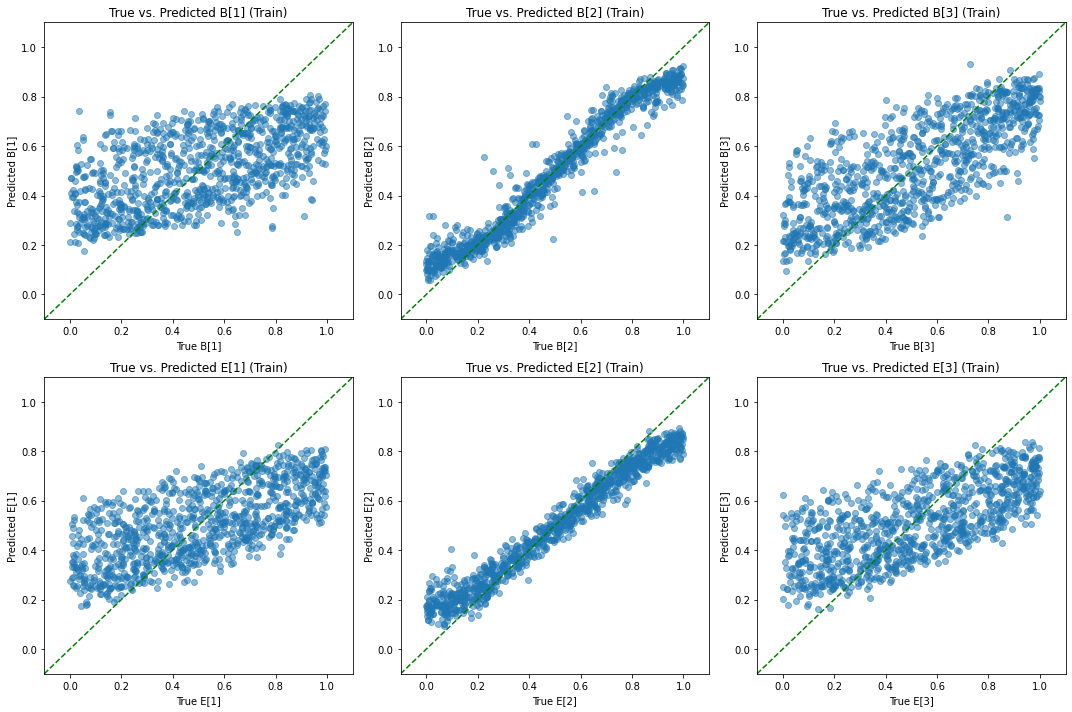

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

for i in range(3):
    plt.subplot(2, 3, i+1)
    plt.scatter(train_target_data_subset[:, i], predictions_train[:, i], alpha=0.5)
    plt.plot([-0.1, 1.1], [-0.1, 1.1], 'g--')
    plt.xlabel(f'True B[{i+1}]')
    plt.ylabel(f'Predicted B[{i+1}]')
    plt.xlim(-0.1, 1.1)
    plt.ylim(-0.1, 1.1)
    plt.title(f'True vs. Predicted B[{i+1}] (Train)')

for i in range(3):
    plt.subplot(2, 3, i+4)
    plt.scatter(train_target_data_subset[:, i+3], predictions_train[:, i+3], alpha=0.5)
    plt.plot([-0.1, 1.1], [-0.1, 1.1], 'g--')
    plt.xlabel(f'True E[{i+1}]')
    plt.ylabel(f'Predicted E[{i+1}]')
    plt.xlim(-0.1, 1.1)
    plt.ylim(-0.1, 1.1)
    plt.title(f'True vs. Predicted E[{i+1}] (Train)')

plt.tight_layout()
figure_train_file = os.path.join("/home/botingl/machine learning", generate_filename("true_vs_predictions_train", "png"))
plt.savefig(figure_train_file, dpi=300, facecolor='white')
plt.show()

In [ ]:
predictions_test = model.predict(I_test)

mae_test = mean_absolute_error(target_test_scaled, predictions_test)
rmse_test = np.sqrt(mean_squared_error(target_test_scaled, predictions_test))
r2_test = r2_score(target_test_scaled, predictions_test)
nrmse_test = np.sqrt(np.mean((target_test_scaled - predictions_test) ** 2)) / (target_test_scaled.max() - target_test_scaled.min())

print(f'NRMSE (Test): {nrmse_test:.2f}')
print(f'Mean Absolute Error (MAE, Test): {mae_test}')
print(f'Root Mean Squared Error (RMSE, Test): {rmse_test}')
print(f'R^2 Score (Test): {r2_test}')

# Scale back the predicted values to original range for the test data
B_pred_test = np.column_stack((
    scaler_B1.inverse_transform(predictions_test[:, 0].reshape(-1, 1)),
    scaler_B2.inverse_transform(predictions_test[:, 1].reshape(-1, 1)),
    scaler_B3.inverse_transform(predictions_test[:, 2].reshape(-1, 1))
))

E_pred_test = np.column_stack((
    scaler_E1.inverse_transform(predictions_test[:, 3].reshape(-1, 1)),
    scaler_E2.inverse_transform(predictions_test[:, 4].reshape(-1, 1)),
    scaler_E3.inverse_transform(predictions_test[:, 5].reshape(-1, 1))
))

# Scale back the true values to original range for the test data
B_true_test = np.column_stack((
    scaler_B1.inverse_transform(target_test_scaled[:, 0].reshape(-1, 1)),
    scaler_B2.inverse_transform(target_test_scaled[:, 1].reshape(-1, 1)),
    scaler_B3.inverse_transform(target_test_scaled[:, 2].reshape(-1, 1))
))

E_true_test = np.column_stack((
    scaler_E1.inverse_transform(target_test_scaled[:, 3].reshape(-1, 1)),
    scaler_E2.inverse_transform(target_test_scaled[:, 4].reshape(-1, 1)),
    scaler_E3.inverse_transform(target_test_scaled[:, 5].reshape(-1, 1))
))

# Calculate evaluation metrics separately for each B and E component for the test set

# B1
mae_test_B1 = mean_absolute_error(B_true_test[:, 0], B_pred_test[:, 0])
rmse_test_B1 = np.sqrt(mean_squared_error(B_true_test[:, 0], B_pred_test[:, 0]))
r2_test_B1 = r2_score(B_true_test[:, 0], B_pred_test[:, 0])

# B2
mae_test_B2 = mean_absolute_error(B_true_test[:, 1], B_pred_test[:, 1])
rmse_test_B2 = np.sqrt(mean_squared_error(B_true_test[:, 1], B_pred_test[:, 1]))
r2_test_B2 = r2_score(B_true_test[:, 1], B_pred_test[:, 1])

# B3
mae_test_B3 = mean_absolute_error(B_true_test[:, 2], B_pred_test[:, 2])
rmse_test_B3 = np.sqrt(mean_squared_error(B_true_test[:, 2], B_pred_test[:, 2]))
r2_test_B3 = r2_score(B_true_test[:, 2], B_pred_test[:, 2])

# E1
mae_test_E1 = mean_absolute_error(E_true_test[:, 0], E_pred_test[:, 0])
rmse_test_E1 = np.sqrt(mean_squared_error(E_true_test[:, 0], E_pred_test[:, 0]))
r2_test_E1 = r2_score(E_true_test[:, 0], E_pred_test[:, 0])

# E2
mae_test_E2 = mean_absolute_error(E_true_test[:, 1], E_pred_test[:, 1])
rmse_test_E2 = np.sqrt(mean_squared_error(E_true_test[:, 1], E_pred_test[:, 1]))
r2_test_E2 = r2_score(E_true_test[:, 1], E_pred_test[:, 1])

# E3
mae_test_E3 = mean_absolute_error(E_true_test[:, 2], E_pred_test[:, 2])
rmse_test_E3 = np.sqrt(mean_squared_error(E_true_test[:, 2], E_pred_test[:, 2]))
r2_test_E3 = r2_score(E_true_test[:, 2], E_pred_test[:, 2])

# Print metrics for test set
print(f"Test MAE - B1: {mae_test_B1}, B2: {mae_test_B2}, B3: {mae_test_B3}")
print(f"Test RMSE - B1: {rmse_test_B1}, B2: {rmse_test_B2}, B3: {rmse_test_B3}")
print(f"Test R2 - B1: {r2_test_B1}, B2: {r2_test_B2}, B3: {r2_test_B3}")

print(f"Test MAE - E1: {mae_test_E1}, E2: {mae_test_E2}, E3: {mae_test_E3}")
print(f"Test RMSE - E1: {rmse_test_E1}, E2: {rmse_test_E2}, E3: {rmse_test_E3}")
print(f"Test R2 - E1: {r2_test_E1}, E2: {r2_test_E2}, E3: {r2_test_E3}")


 1/63 [..............................] - ETA: 1s

63/63 [==============================] - 0s 1ms/step
NRMSE (Test): 0.18
Mean Absolute Error (MAE, Test): 0.1406708247050194
Root Mean Squared Error (RMSE, Test): 0.1840209134361025
R^2 Score (Test): 0.5953847605207274
Test MAE - B1: 0.03819348721878971, B2: 0.011435751218560731, B3: 0.03502574333284991
Test RMSE - B1: 0.045542477051410485, B2: 0.015584133720843326, B3: 0.042801892593678004
Test R2 - B1: 0.4053149761928856, B2: 0.9264151040280617, B3: 0.4484546761384355
Test MAE - E1: 322.2813525924237, E2: 114.59356392972471, E3: 320.22285951110405
Test RMSE - E1: 387.6567865333691, E2: 147.3902710161506, E3: 387.3354409069035
Test R2 - E1: 0.43298505892052663, E2: 0.9193950010099146, E3: 0.43974374506972225


In [ ]:
metrics_test_file = os.path.join("/home/botingl/machine learning", generate_filename("evaluation_metrics_test", "txt"))
with open(metrics_test_file, "w") as f:
    f.write(f"Mean Absolute Error (MAE): {mae_test}\n")
    f.write(f"Root Mean Squared Error (RMSE): {rmse_test}\n")
    f.write(f"R^2 Score: {r2_test}\n")
    f.write(f"Normalized RMSE (NRMSE): {nrmse_test}\n")

Plot the true vs. predicted B and E values for the test set

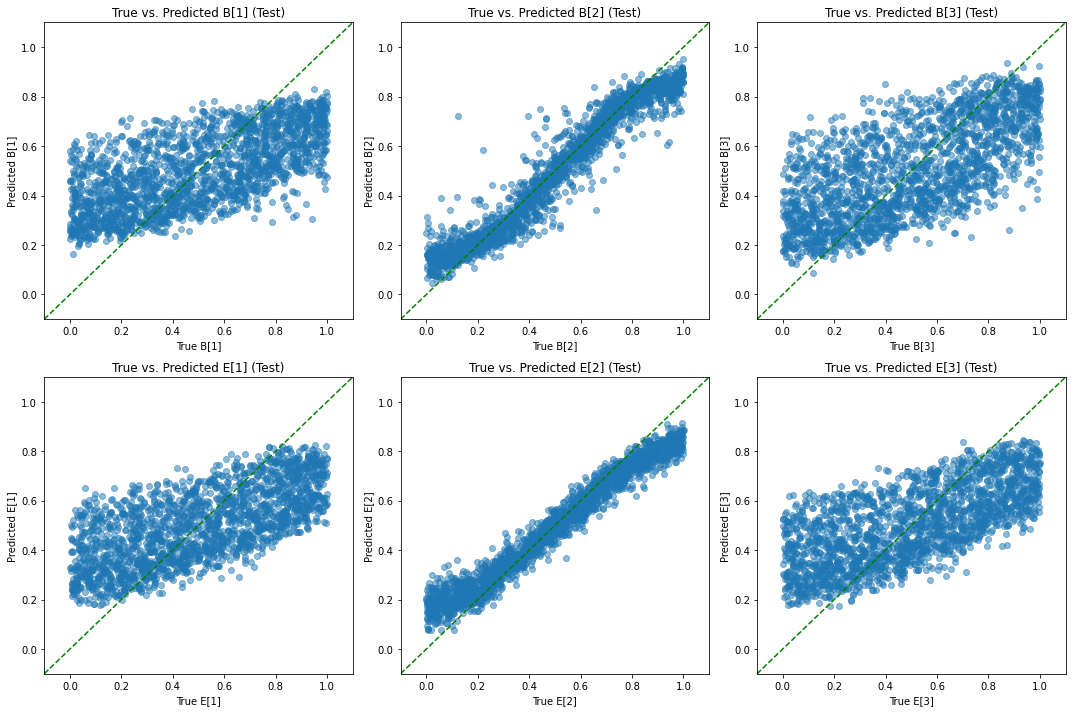

In [ ]:
plt.figure(figsize=(15, 10))
for i in range(3):
    plt.subplot(2, 3, i+1)
    plt.scatter(target_test_scaled[:, i], predictions_test[:, i], alpha=0.5)
    plt.plot([-0.1, 1.1], [-0.1, 1.1], 'g--')
    plt.xlabel(f'True B[{i+1}]')
    plt.ylabel(f'Predicted B[{i+1}]')
    plt.xlim(-0.1, 1.1)
    plt.ylim(-0.1, 1.1)
    plt.title(f'True vs. Predicted B[{i+1}] (Test)')

for i in range(3):
    plt.subplot(2, 3, i+4)
    plt.scatter(target_test_scaled[:, i+3], predictions_test[:, i+3], alpha=0.5)
    plt.plot([-0.1, 1.1], [-0.1, 1.1], 'g--')
    plt.xlabel(f'True E[{i+1}]')
    plt.ylabel(f'Predicted E[{i+1}]')
    plt.xlim(-0.1, 1.1)
    plt.ylim(-0.1, 1.1)
    plt.title(f'True vs. Predicted E[{i+1}] (Test)')

plt.tight_layout()
figure_test_file = os.path.join("/home/botingl/machine learning", generate_filename("true_vs_predictions_test", "png"))
plt.savefig(figure_test_file, dpi=300, facecolor='white')
plt.show()